# Regresion polinomical

No todas las regresiones se comportan lineal, hay caso donde cuando miramos 
o mostramos el modelo este puede ser no lineal, cuando la distribucion 
de los datos sufre una curvatura en el espacio.

este tipo de modelos no se ajustan a la ecuacion lineal debido a que su 
pendiente es variable con respecto a los movimientos del intecepto

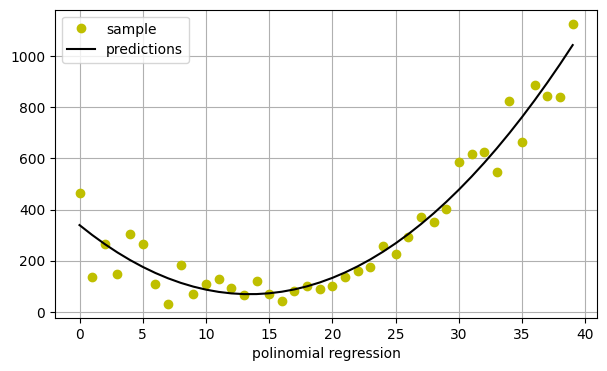

In [5]:
import matplotlib.pyplot as plt
import random

def polinomial_regression(X,y):
    a12=0;a13=0;a14=0;a23=0;a24=0;a33=0;a34=0
    for i in range(len(X)):
        x_e2 = X[i]*X[i]; x_e3=x_e2*X[i]; x_e4=x_e3*X[i]
        a12 += X[i]; a13 += x_e2; a14 += y[i]
        a23 += x_e3; a24 += X[i]*y[i]
        a33 += x_e4; a34 +=x_e2*y[i]
    
    a11 = len(X); a21=a12; a22=a13; a31=a13; a32=a23

    aux1 = a23/a13; aux2 = a33/a13
    b11 = aux1*a11-a21; b12= aux1*a12-a22; b13=aux1*a14-a24
    b21 = aux2*a11-a31; b22 = aux2*a12-a32;b23=aux2*a14-a34

    a0 = ((b22/b12)*b13-b23)/((b22/b12)*b11-b21)
    a1 = (b23-b21 * a0)/b22
    a2 = (a24-a21*a0-a22*a1)/a23
    return a0,a1,a2

def prediction(a0,a1,a2,x):
    return a0+a1*x+a2*x*x

fig,axs = plt.subplots(figsize=(7,4))

X = list(range(40))
y = []

for i in range(len(X)):
    y.append((X[i]-10)**2+random.random()*20*abs(len(X)/2-i))

y_prediction = []
a0,a1,a2 = polinomial_regression(X,y)

for i in range(len(X)):
    y_prediction.append(prediction(a0,a1,a2,X[i]))

axs.plot(X,y,'yo',label='sample')
axs.plot(X,y_prediction,'k-',label='predictions')
axs.set_xlabel('polinomial regression')
axs.legend();axs.grid();
plt.show()